##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [12]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [13]:
## **Step 1: Download and Extract the UCF11 Dataset**

# Downloading the UCF11 (YouTube Action) Dataset
!wget -nc --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar

# Extracting the dataset 
!unrar x UCF11_updated_mpg.rar -inul -y

File ‘UCF11_updated_mpg.rar’ already there; not retrieving.



In [14]:
## **Step 2: Read & Preprocess the Dataset**

image_height, image_width = 64, 64
max_images_per_class = 8000

# The extracted UCF11 directory name
dataset_directory = "UCF11_updated_mpg"

# Choosing 3 classes from the UCF11 dataset (Note: tennis folder is named tennis_swing)
classes_list = ["basketball", "biking", "tennis_swing"]

model_output_size = len(classes_list)

In [15]:
### **Extract, Resize & Normalize Frames**

def frames_extraction(video_path):
    # Empty List declared to store video frames
    frames_list = []
    
    # Reading the Video File Using the VideoCapture
    video_reader = cv2.VideoCapture(video_path)

    # Iterating through Video Frames
    while True:
        # Reading a frame from the video file 
        success, frame = video_reader.read() 

        # If Video frame was not successfully read then break the loop
        if not success:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame
        normalized_frame = resized_frame / 255
        
        # Appending the normalized frame into the frames list
        frames_list.append(normalized_frame)
    
    # Closing the VideoCapture object
    video_reader.release()

    return frames_list

In [16]:
### **Dataset Creation**

def create_dataset():
    # Declaring Empty Lists to store the features and labels values
    temp_features = [] 
    features = []
    labels = []
    
    # Iterating through all the classes mentioned in the classes list
    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}')
        
        class_dir = os.path.join(dataset_directory, class_name)

        # UCF11 structure includes subdirectories for video groups
        for group_name in os.listdir(class_dir):
            group_dir = os.path.join(class_dir, group_name)
            
            # Ensure it is a directory before proceeding
            if os.path.isdir(group_dir):
                for file_name in os.listdir(group_dir):
                    video_file_path = os.path.join(group_dir, file_name)
                    frames = frames_extraction(video_file_path)
                    temp_features.extend(frames)
        
        # Handling the possibility of having fewer frames than max_images_per_class
        samples_to_take = min(max_images_per_class, len(temp_features))
        
        # Adding randomly selected frames to the features list
        features.extend(random.sample(temp_features, samples_to_take))

        # Adding Fixed number of labels to the labels list
        labels.extend([class_index] * samples_to_take)
        
        # Emptying the temp_features list
        temp_features.clear()

    # Converting the features and labels lists to numpy arrays
    features = np.asarray(features)
    labels = np.array(labels)  

    return features, labels

features, labels = create_dataset()

# Converting labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

Extracting Data of Class: basketball
Extracting Data of Class: biking
Extracting Data of Class: tennis_swing


In [17]:
## **Step 3: Split the Data into Train and Test Set**

features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels, test_size = 0.2, shuffle = True, random_state = seed_constant
)

In [18]:
## **Step 4: Construct the Model**

def create_model():
    # We will use a Sequential model for model construction
    model = Sequential()

    # Defining The Model Architecture
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', input_shape = (image_height, image_width, 3)))
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation = 'softmax'))

    # Printing the models summary
    model.summary()

    return model

# Calling the create_model method
model = create_model()

print("Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


In [20]:
## **Step 5: Compile and Train the Model**

# Adding the Early Stopping Callback
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Adding loss, optimizer and metrics values to the model
model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start Training
model_training_history = model.fit(
    x = features_train, y = labels_train, epochs = 5, batch_size = 4, 
    shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback]
)

Epoch 1/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9338 - loss: 0.1948 - val_accuracy: 0.8878 - val_loss: 0.3038
Epoch 2/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9366 - loss: 0.1799 - val_accuracy: 0.9380 - val_loss: 0.1807
Epoch 3/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9443 - loss: 0.1644 - val_accuracy: 0.9859 - val_loss: 0.0449
Epoch 4/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9492 - loss: 0.1484 - val_accuracy: 0.9792 - val_loss: 0.0553
Epoch 5/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9497 - loss: 0.1444 - val_accuracy: 0.9779 - val_loss: 0.0740


In [21]:
## **Step 6: Save the Trained Model**

model_evaluation_history = model.evaluate(features_test, labels_test)

# Saving the model
student_name = "Lujeen"
save_path = f"{student_name}_ucf11_model.h5"

model.save(save_path)
print(f"Model saved as {save_path}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9867 - loss: 0.0446


Model saved as Lujeen_ucf11_model.h5


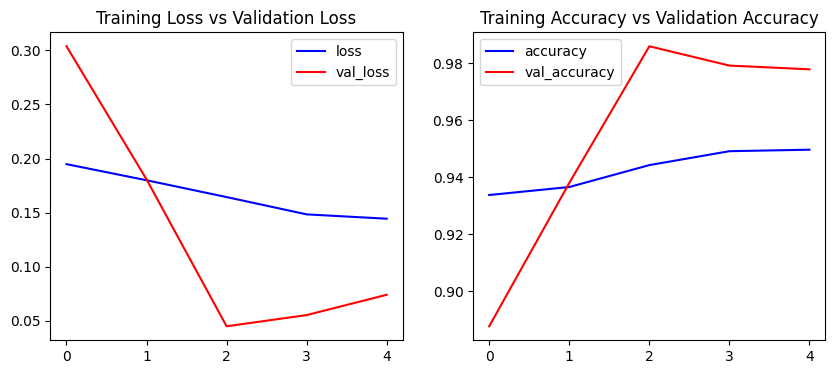

In [22]:
## **Step 7: Plot the Model’s Loss and Accuracy Curves**

def plot_metric(metric_name_1, metric_name_2, plot_name):
    # Get Metric values using metric names as identifiers
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Constructing a range object which will be used as time 
    epochs = range(len(metric_value_1))
  
    # Plotting the Graph
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)
  
    # Adding title and legend
    plt.title(str(plot_name))
    plt.legend()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_metric('loss', 'val_loss', 'Training Loss vs Validation Loss')

plt.subplot(1, 2, 2)
plot_metric('accuracy', 'val_accuracy', 'Training Accuracy vs Validation Accuracy')
plt.show()

In [24]:
## **Step 8: Make Predictions on External Videos**

def predict_on_live_video(video_file_path, output_file_path, window_size):
    # Initialize a Deque Object
    predicted_labels_probabilities_deque = deque(maxlen = window_size)

    # Reading the Video File
    video_reader = cv2.VideoCapture(video_file_path)

    # Getting the width and height of the video 
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Writing the Overlayed Video Files
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'), 24, (original_video_width, original_video_height))

    while True: 
        status, frame = video_reader.read() 
        if not status:
            break

        # Resize and Normalize
        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255

        # Receiving Predicted Probabilities
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose=0)[0]
        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        # Averaging process
        if len(predicted_labels_probabilities_deque) == window_size:
            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)
            
            predicted_label = np.argmax(predicted_labels_probabilities_averaged)
            predicted_class_name = classes_list[predicted_label]
          
            # Overlaying Class Name
            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Writing The Frame
        video_writer.write(frame)

    video_reader.release()
    video_writer.release()

In [25]:
# Validating on 3 YouTube videos

output_directory = 'Youtube_Videos'
os.makedirs(output_directory, exist_ok=True)
window_size = 25

# 1. Basketball Video
input_video_1 = f'{output_directory}/basketball_test.mp4'
output_video_1 = f'{output_directory}/basketball_test_Output.mp4'
predict_on_live_video(input_video_1, output_video_1, window_size)
print("Finished validating Video 1 (Basketball)")

# 2. Biking Video
input_video_2 = f'{output_directory}/biking_test.mp4'
output_video_2 = f'{output_directory}/biking_test_Output.mp4'
predict_on_live_video(input_video_2, output_video_2, window_size)
print("Finished validating Video 2 (Biking)")

# 3. Tennis Video
input_video_3 = f'{output_directory}/tennis_test.mp4'
output_video_3 = f'{output_directory}/tennis_test_Output.mp4'
predict_on_live_video(input_video_3, output_video_3, window_size)
print("Finished validating Video 3 (Tennis)")

Finished validating Video 1 (Basketball)
Finished validating Video 2 (Biking)
Finished validating Video 3 (Tennis)


In [26]:
## **Step 9: Make Average Predictions**

def make_average_predictions(video_file_path, predictions_frames_count):
    # Initializing the Numpy array which will store Prediction Probabilities
    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype = float)

    # Reading the Video File using the VideoCapture Object
    video_reader = cv2.VideoCapture(video_file_path)

    # Getting The Total Frames present in the video 
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculating The Number of Frames to skip Before reading a frame
    skip_frames_window = max(1, video_frames_count // predictions_frames_count)

    for frame_counter in range(predictions_frames_count): 
        # Setting Frame Position
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Reading The Frame
        status, frame = video_reader.read() 
        if not status:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame
        normalized_frame = resized_frame / 255

        # Passing the Image Normalized Frame to the model
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose=0)[0]

        # Appending predicted label probabilities
        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    # Calculating Average of Predicted Labels Probabilities Column Wise 
    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

    # Sorting the Averaged Predicted Labels Probabilities
    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    print(f"\nPredictions for: {os.path.basename(video_file_path)}")
    
    # Iterating Over All Averaged Predicted Label Probabilities
    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:
        predicted_class_name = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS NAME: {predicted_class_name:<15} AVERAGED PROBABILITY: {predicted_probability:.2f}")    

    # Closing the VideoCapture Object
    video_reader.release()

# Calling The Make Average Method To Start The Process for all 3 videos
print("Starting Average Predictions...")
make_average_predictions(input_video_1, 50)
make_average_predictions(input_video_2, 50)
make_average_predictions(input_video_3, 50)

Starting Average Predictions...

Predictions for: basketball_test.mp4
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.00
CLASS NAME: biking          AVERAGED PROBABILITY: 0.00
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.00

Predictions for: biking_test.mp4
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.00
CLASS NAME: biking          AVERAGED PROBABILITY: 0.00
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.00

Predictions for: tennis_test.mp4
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.00
CLASS NAME: biking          AVERAGED PROBABILITY: 0.00
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.00
